/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_99449/2257360980.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_column] = pd.to_datetime(df[date_column], errors="coerce")


Generated and saved: pH_plot.pdf


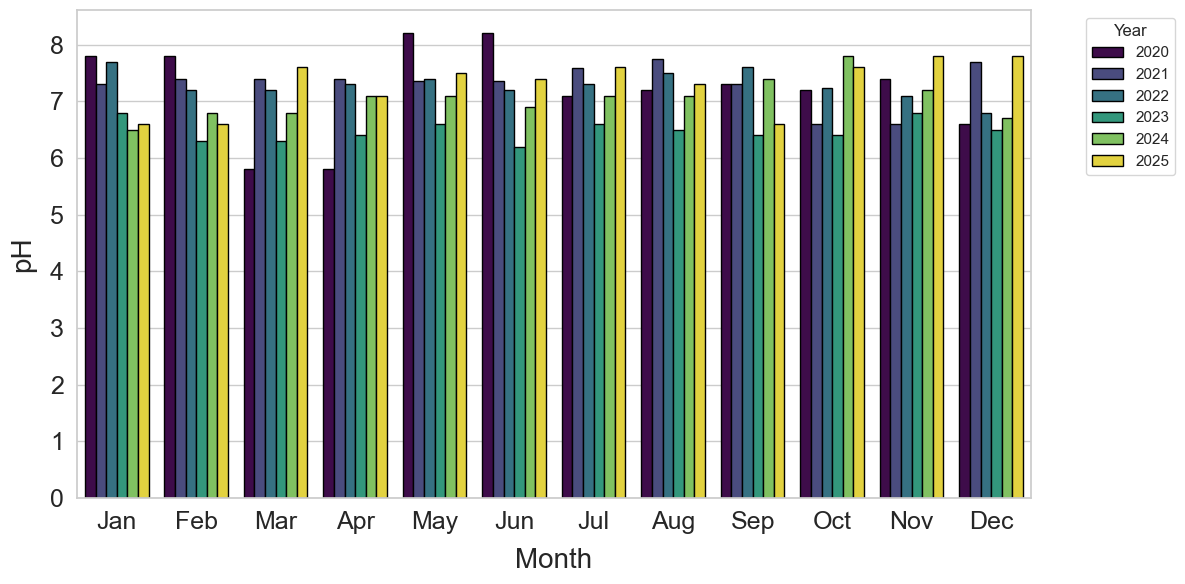

Generated and saved: COD__mg_L__plot.pdf


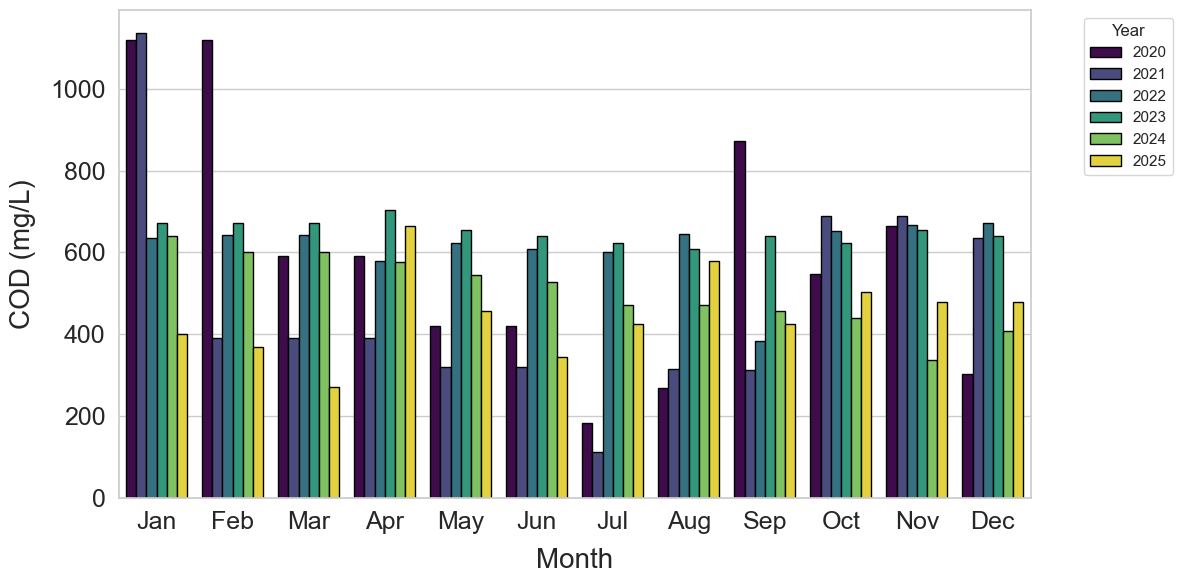

Generated and saved: BOD__mg_L__plot.pdf


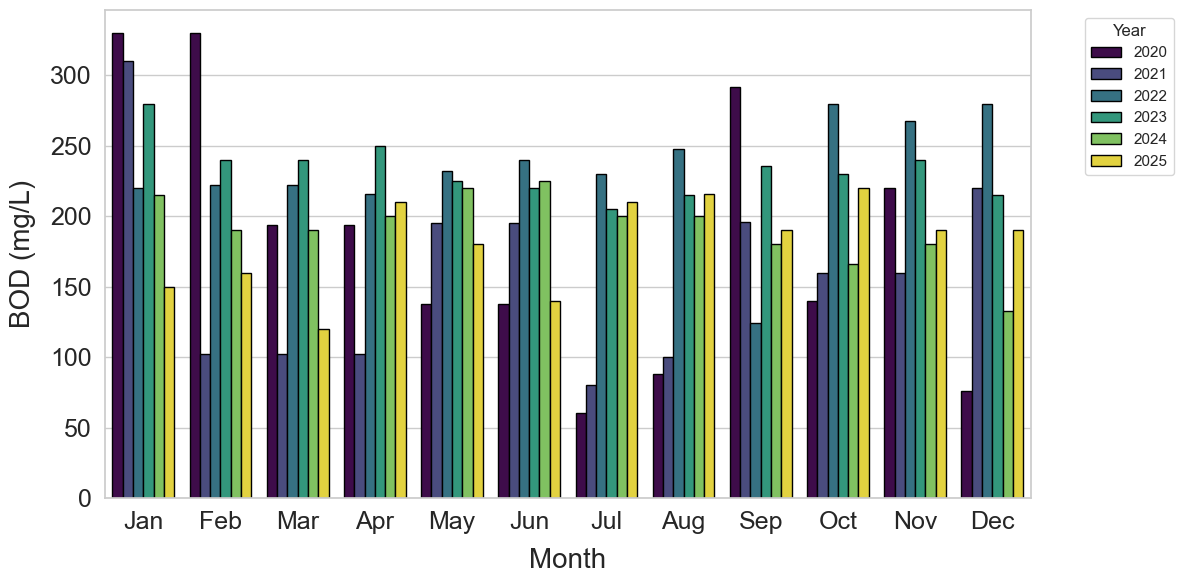

Generated and saved: TSS_plot.pdf


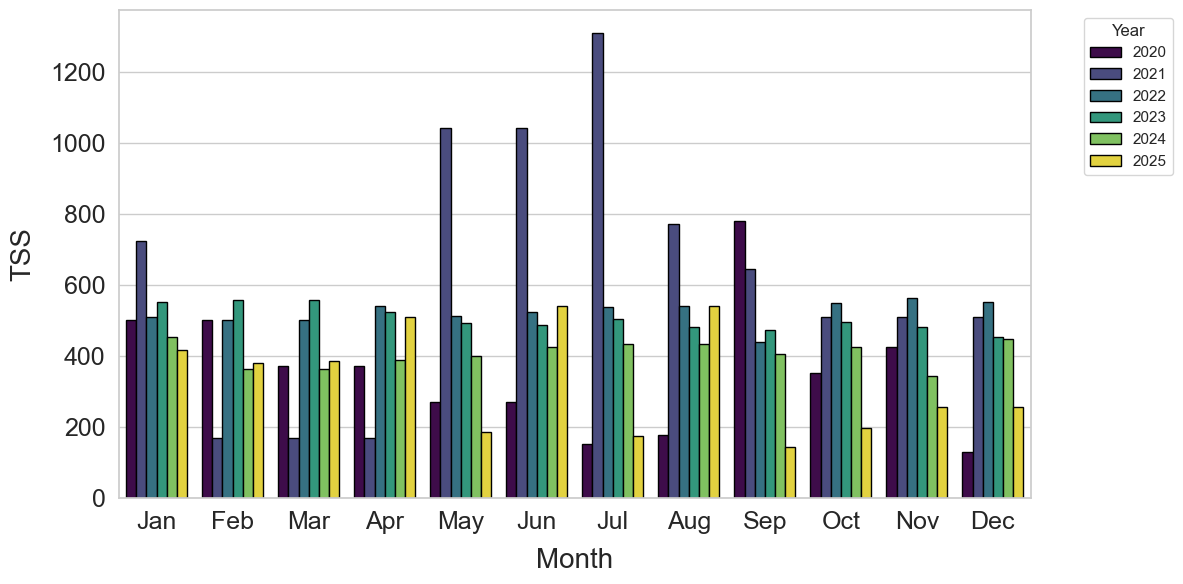

Generated and saved: Oil___Grease__mg_L__plot.pdf


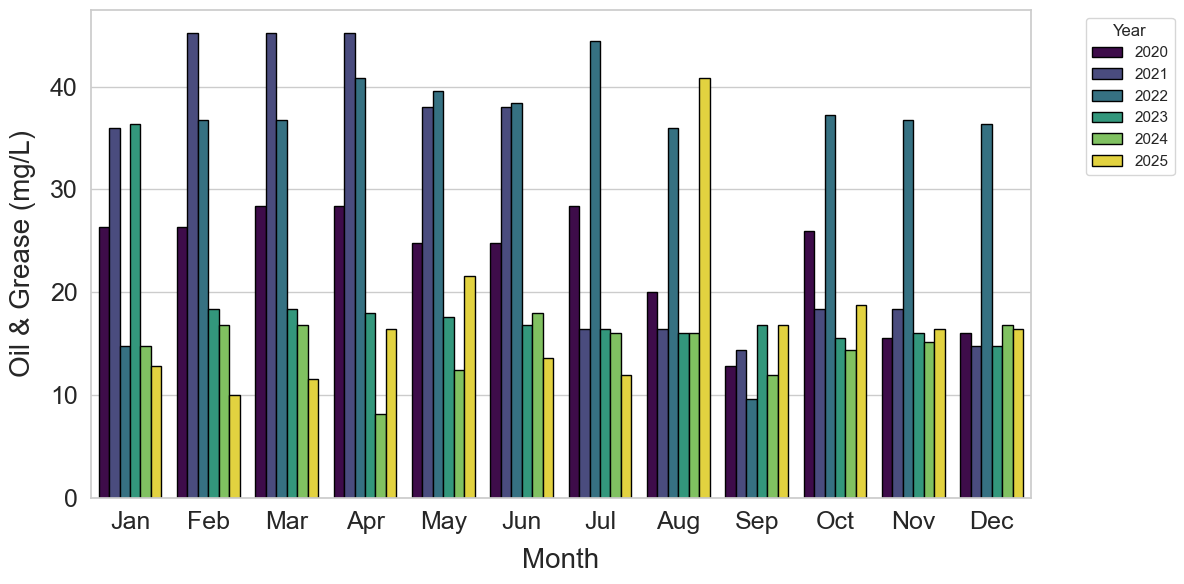

Generated and saved: Ammonical_Nitrogen__mg_L__plot.pdf


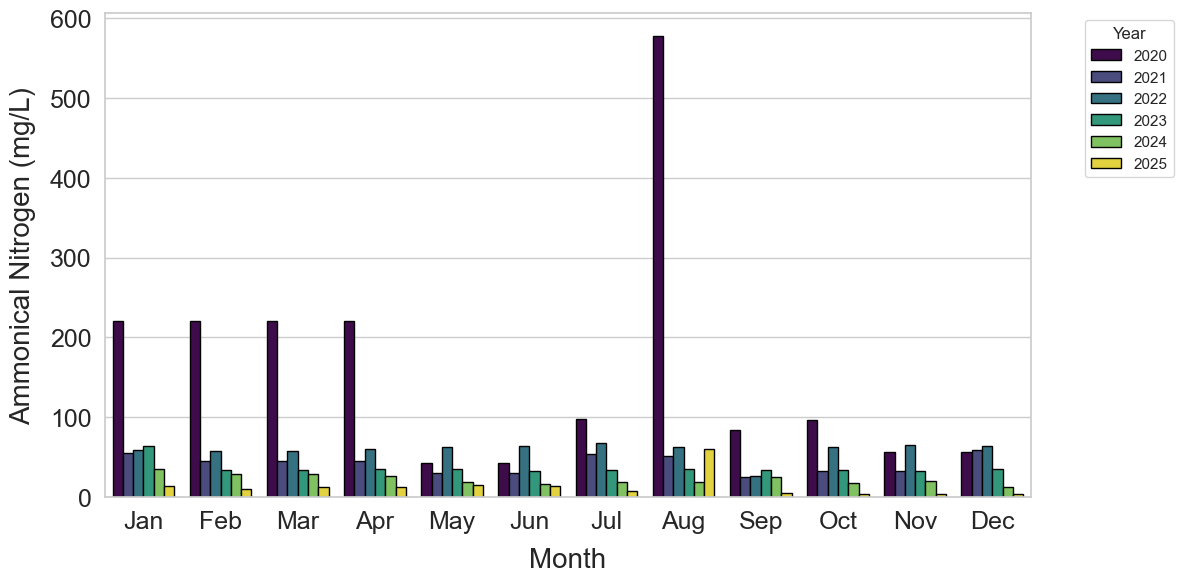

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_pollution_data(csv_file_path, date_column):

    try:
        df = pd.read_csv('/Users/andydascikid/Downloads/DPCC Data.csv')
    except FileNotFoundError:
        print(f"Error: The file at {csv_file_path} was not found.")
        return
    
    df[date_column] = pd.to_datetime(df[date_column], errors="coerce")

    if df[date_column].isnull().any():
        print(
            "Warning: Some dates could not be parsed and those rows will be skipped."
        )
        df = df.dropna(subset=[date_column])

    df["Year"] = df[date_column].dt.year
    df["Month_Num"] = df[date_column].dt.month
    df["Month"] = df[date_column].dt.strftime("%b")  

    df = df.sort_values("Month_Num")

    exclude_cols = [date_column, "Year", "Month_Num", "Month"]
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns

    if len(feature_cols) == 0:
        print("No numerical feature columns found to plot.")
        return

    sns.set_theme(style="whitegrid")  

    for feature in feature_cols:
        plt.figure(figsize=(12, 6))

        ax = sns.barplot(
            data=df,
            x="Month",
            y=feature,
            hue="Year",
            palette="viridis",  
            edgecolor="black",
        )

        plt.xlabel("Month", fontsize=20, labelpad=10)
        plt.ylabel(f"{feature}", fontsize=20, labelpad=10)

        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)

        plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()

        safe_filename = (
            "".join([c if c.isalnum() else "_" for c in feature]) + "_plot.pdf"
        )
        plt.savefig(safe_filename, dpi=300)
        print(f"Generated and saved: {safe_filename}")

        plt.show()

plot_pollution_data(csv_file_path="/Users/andydascikid/Downloads/DPCC Data.csv", date_column="Date")